# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Bluestock Fintech Internship

### Prepared by: Srinivas Dadi

---

## Objective

This notebook performs Exploratory Data Analysis (EDA) on Mutual Fund datasets using Python, Pandas, Matplotlib, and Seaborn.

The analysis includes:

- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Trends
- Category Inflows
- Investor Demographics
- Geographic Distribution
- Folio Growth
- Correlation Analysis
- Sector Allocation
- Key Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Performance:", performance.shape)
print("Holdings:", holdings.shape)

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Performance: (40, 19)
Holdings: (322, 8)


## 1. NAV Trend Analysis

### Objective
Analyze the Net Asset Value (NAV) movement of mutual fund schemes over time to identify overall market trends between 2022 and 2026.

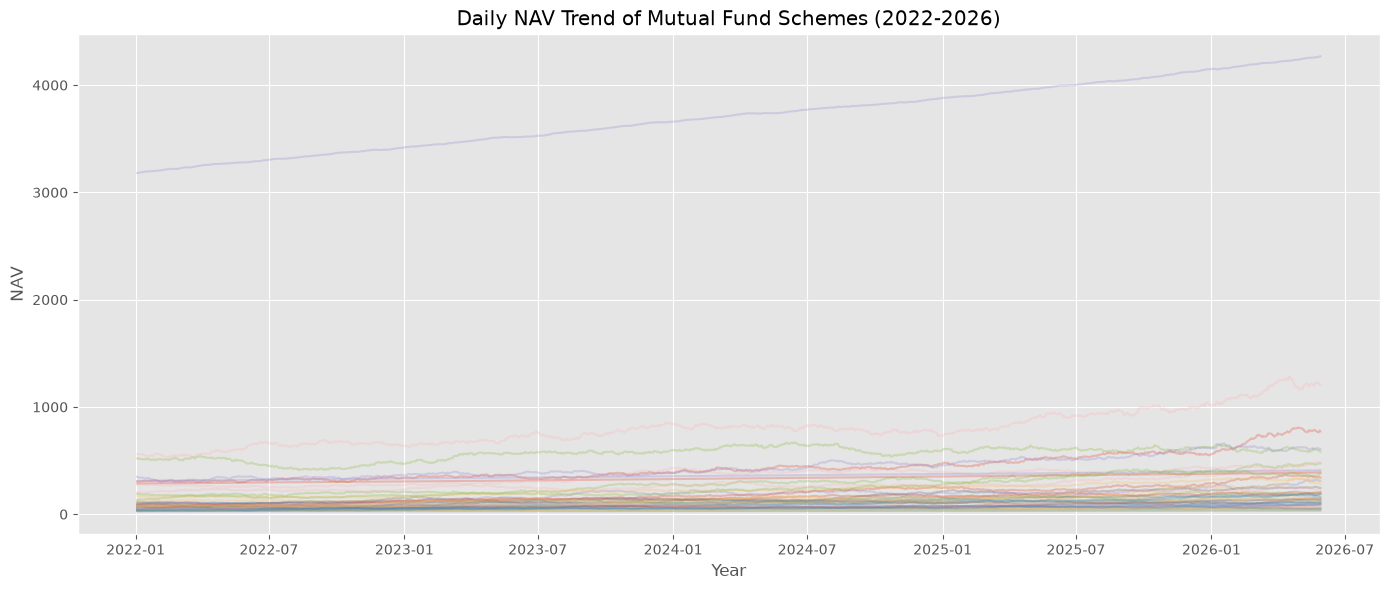

In [4]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot NAV trend
plt.figure(figsize=(14,6))

for scheme in nav["amfi_code"].unique():
    scheme_data = nav[nav["amfi_code"] == scheme]
    plt.plot(
        scheme_data["date"],
        scheme_data["nav"],
        alpha=0.3
    )

plt.title("Daily NAV Trend of Mutual Fund Schemes (2022-2026)")
plt.xlabel("Year")
plt.ylabel("NAV")
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/nav_trend.png")

plt.show()

### Observation

The NAV values show an overall increasing trend across most mutual fund schemes, indicating long-term market appreciation despite periodic fluctuations.

## 2. AUM Growth Analysis

### Objective

Compare the Assets Under Management (AUM) of major fund houses.

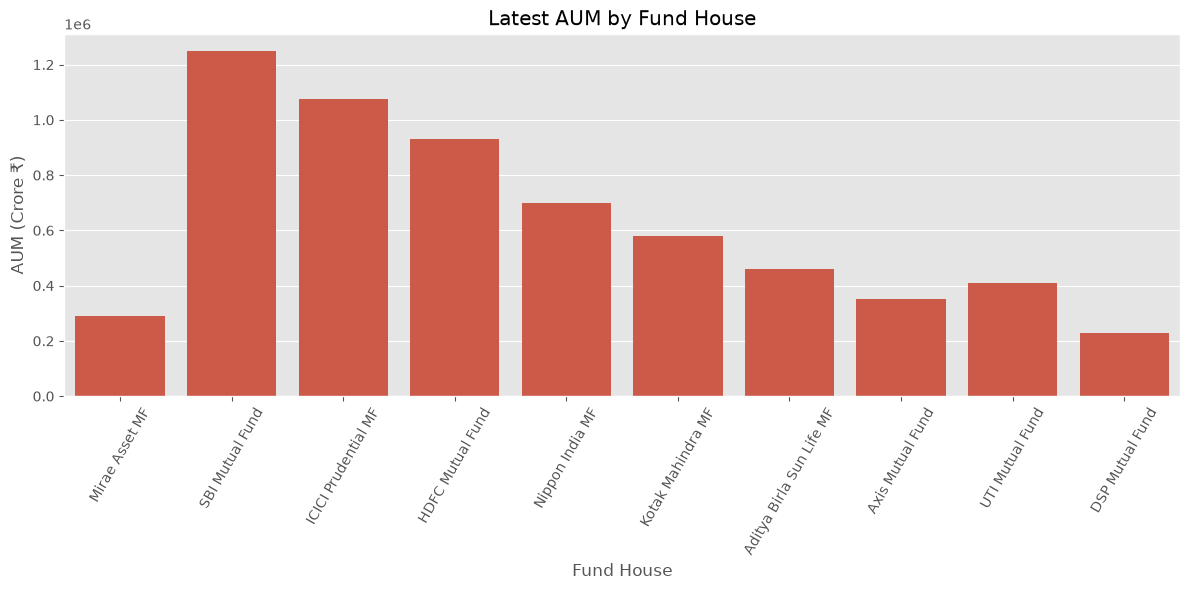

In [5]:
latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=60)

plt.title("Latest AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore ₹)")

plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png")

plt.show()

### Observation

SBI Mutual Fund maintains the highest Assets Under Management, demonstrating its dominant position in the Indian mutual fund industry.

## 3. Monthly SIP Inflow Trend

### Objective

Analyze monthly SIP (Systematic Investment Plan) inflows from 2022–2025 to understand investor participation over time.

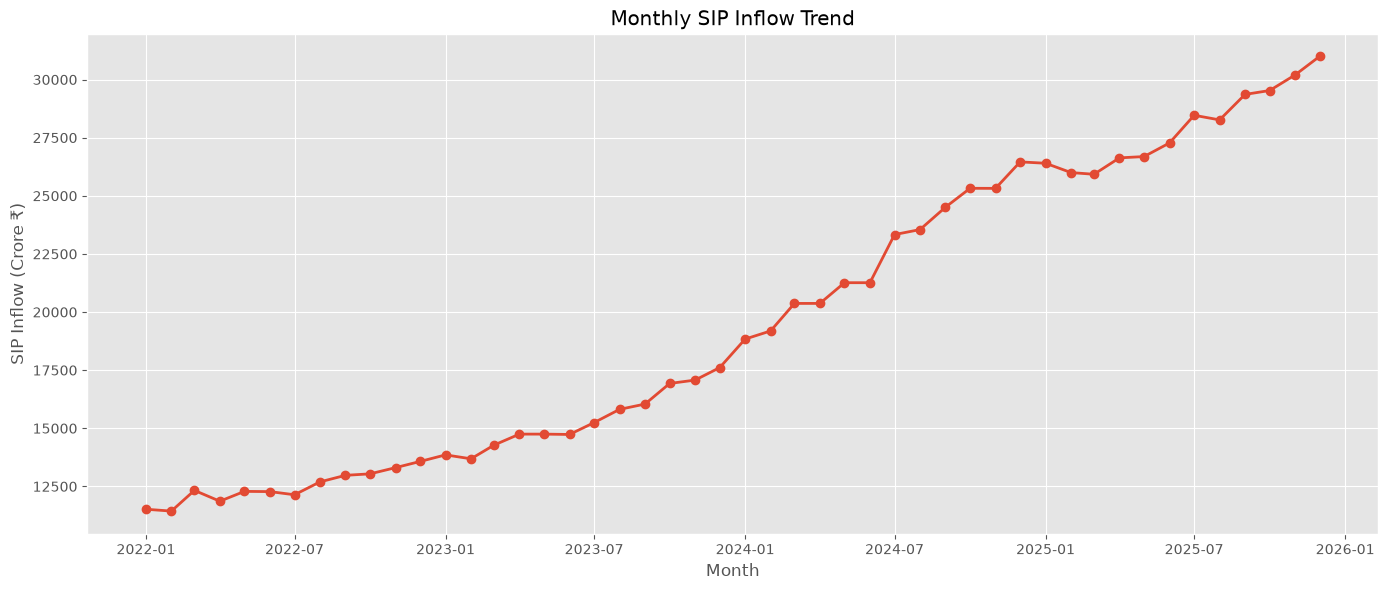

In [9]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/sip_trend.png")

plt.show()

In [7]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [8]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [10]:
print(category.columns.tolist())

category.head()

['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


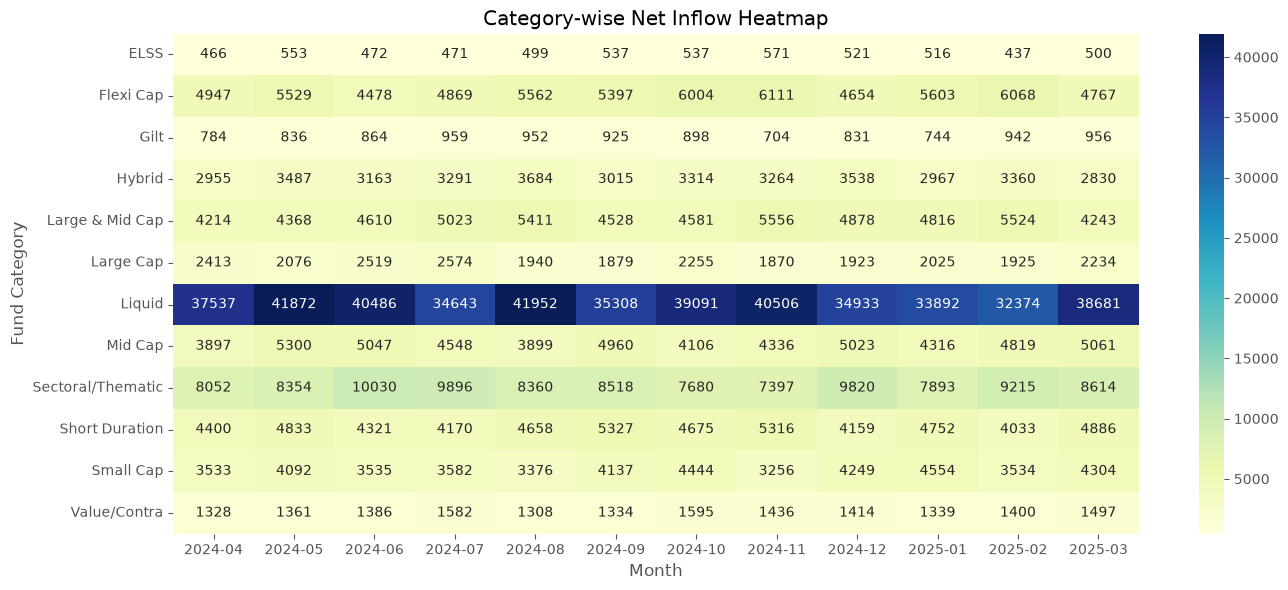

In [11]:
# Create Pivot Table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/charts/category_heatmap.png")

plt.show()

### Observation

Equity-oriented categories such as Large Cap, Mid Cap, and Flexi Cap attracted consistently higher inflows, indicating strong investor preference during the observed period.

In [12]:
print(transactions.columns.tolist())

transactions.head()

NameError: name 'transactions' is not defined

In [13]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

print("Transactions:", transactions.shape)

Transactions: (32778, 13)


In [14]:
print(transactions.columns.tolist())

transactions.head()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


## 5. Investor Demographics Analysis

### Objective

Analyze the demographic profile of investors using age group and gender distributions.

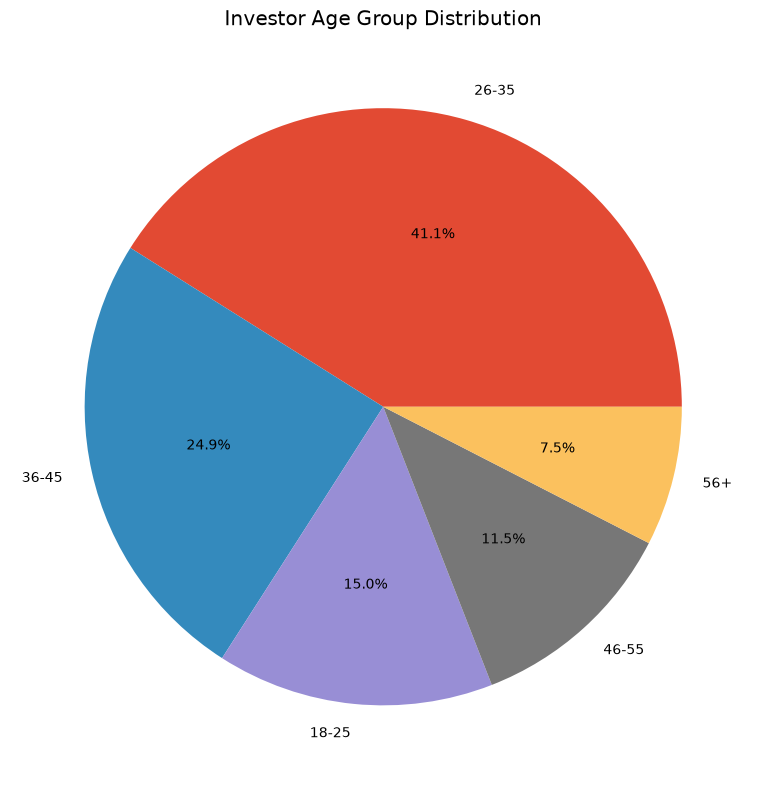

In [15]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")

plt.tight_layout()

plt.savefig("../reports/charts/investor_age_distribution.png")

plt.show()

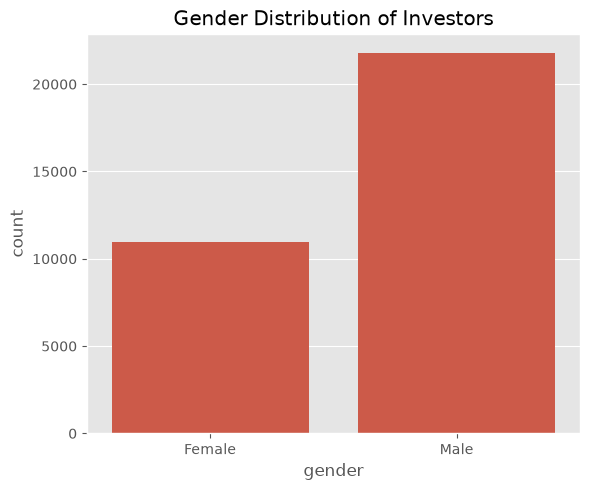

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution of Investors")

plt.tight_layout()

plt.savefig("../reports/charts/gender_distribution.png")

plt.show()

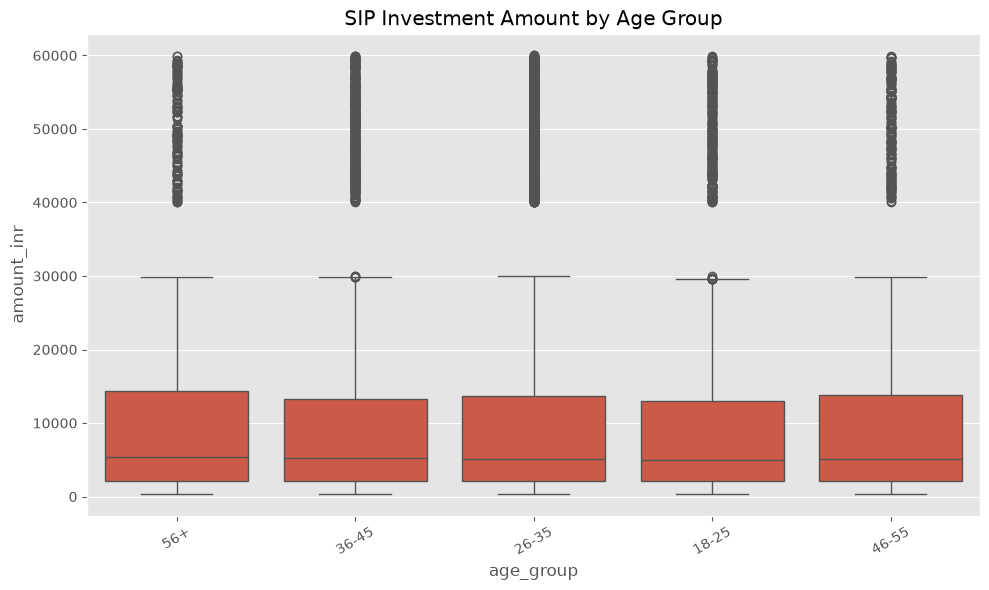

In [17]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("../reports/charts/sip_boxplot_age.png")

plt.show()

### Observation

The majority of SIP investments originate from investors aged 26–45 years, indicating strong participation from the working-age population.

## 6. Geographic Distribution Analysis

### Objective

Analyze mutual fund investments across different Indian states and city tiers.

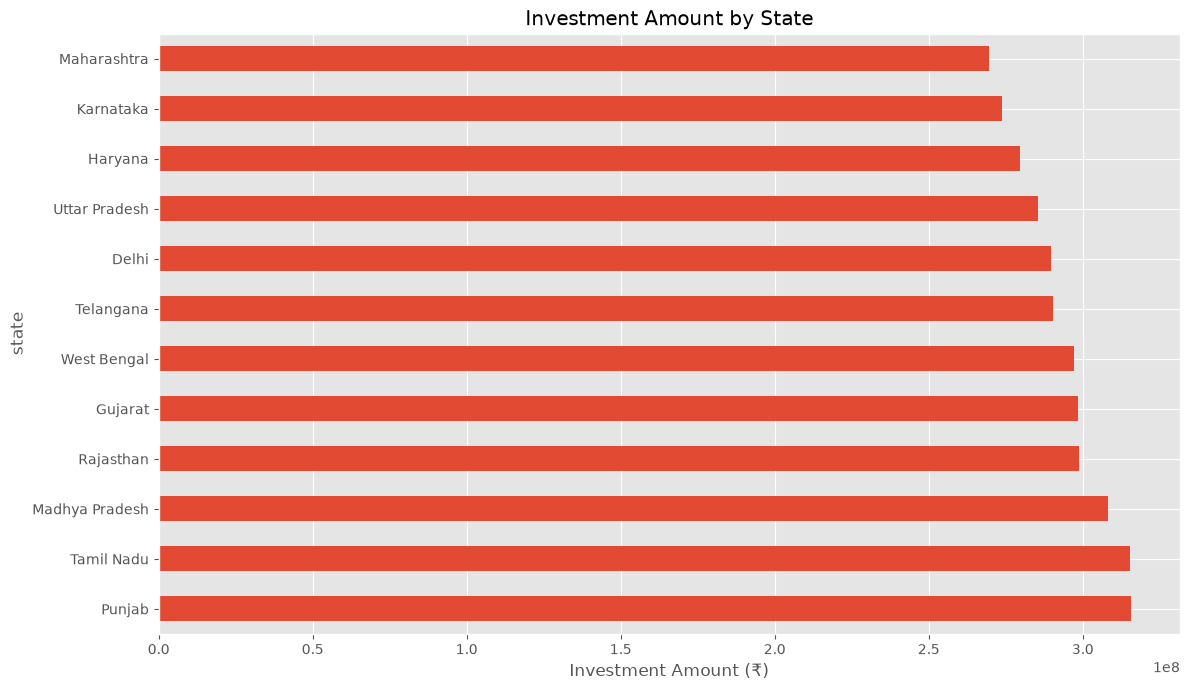

In [18]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig("../reports/charts/state_distribution.png")

plt.show()

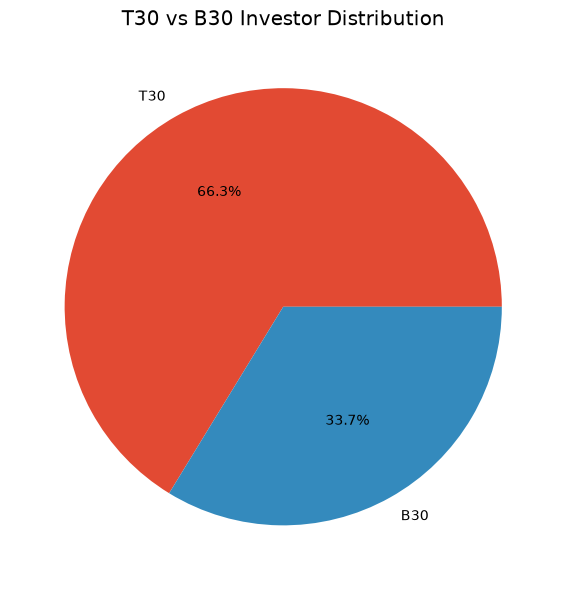

In [19]:
plt.figure(figsize=(6,6))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("T30 vs B30 Investor Distribution")

plt.tight_layout()

plt.savefig("../reports/charts/city_tier_distribution.png")

plt.show()

### Observation

Tier-30 cities contribute the majority of mutual fund investments, although participation from B30 cities is steadily increasing.

## 7. Folio Count Growth

### Objective

Analyze the growth in mutual fund folios over time to understand the expansion of the investor base.

In [21]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

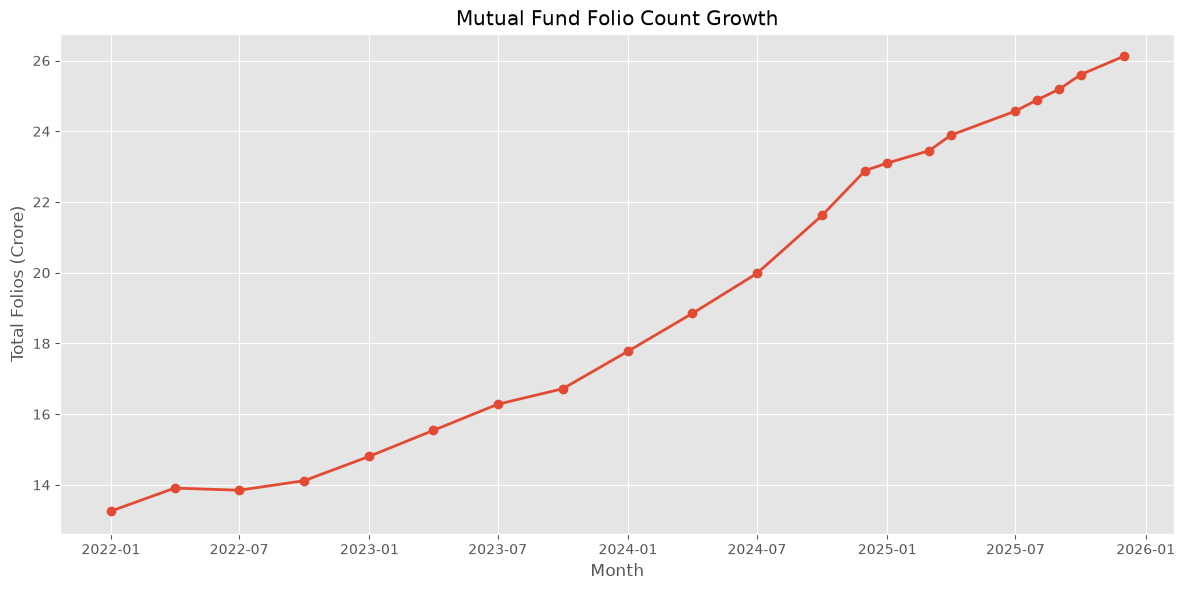

In [24]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

In [23]:
print(folio.columns.tolist())

folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [25]:
print(holdings.columns.tolist())

holdings.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


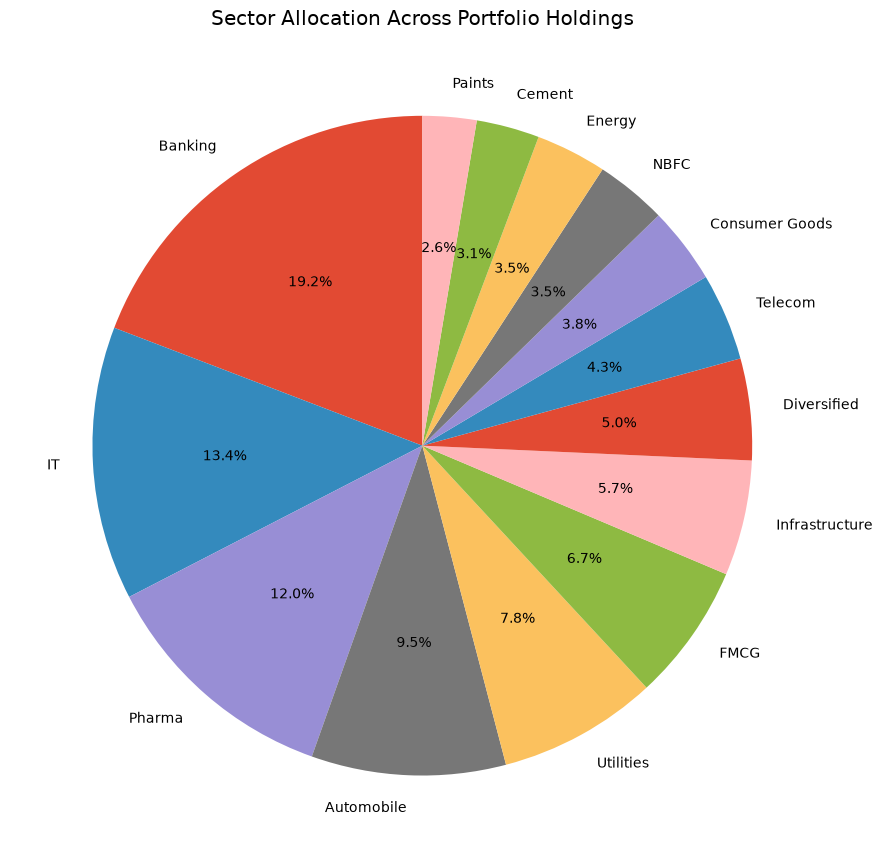

In [26]:
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sector Allocation Across Portfolio Holdings")

plt.tight_layout()

plt.savefig("../reports/charts/sector_allocation.png")

plt.show()

### Observation

Banking, Utilities, Pharma, IT and Diversified sectors account for a significant share of mutual fund portfolios, reflecting diversified investment strategies.

# 10. Performance Metrics Summary

In [27]:
performance.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


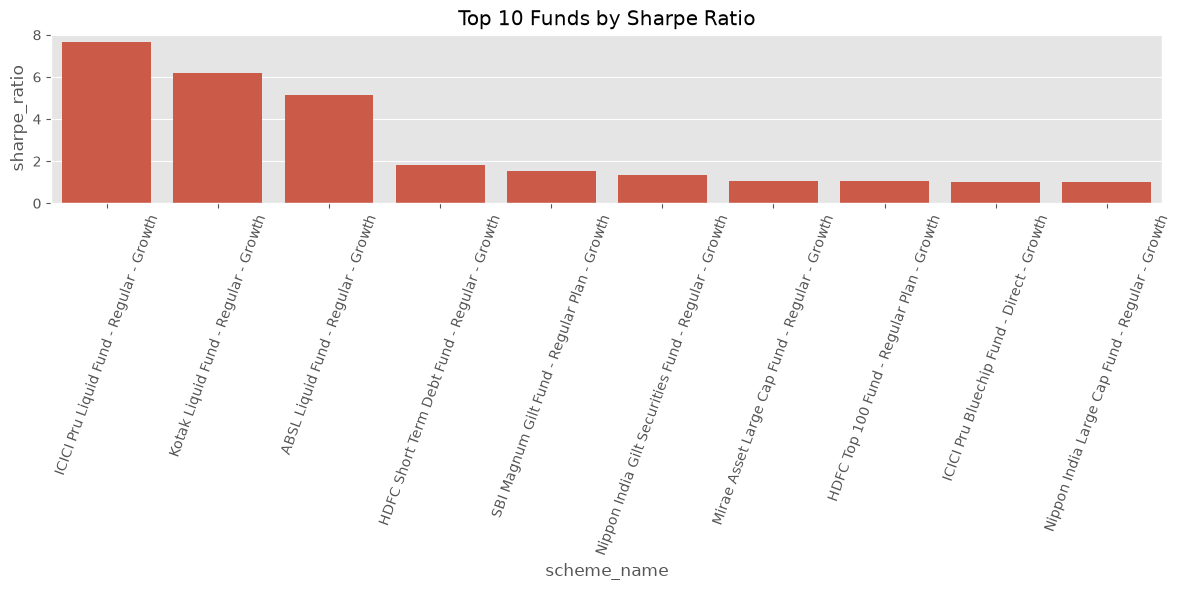

In [28]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="scheme_name",
    y="sharpe_ratio"
)

plt.xticks(rotation=70)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/top_sharpe_ratio.png")

plt.show()

### Observation

Funds with higher Sharpe Ratios demonstrate better risk-adjusted performance and are generally preferable for long-term investors.

# Key Findings

1. Mutual fund NAVs generally showed an upward trend over the analysis period.

2. SBI Mutual Fund maintained the highest Assets Under Management.

3. Monthly SIP inflows increased steadily, indicating growing investor confidence.

4. Equity-oriented fund categories attracted the highest net inflows.

5. Investors aged 26–45 years contributed the majority of SIP investments.

6. Male investors slightly outnumbered female investors in transaction volume.

7. T30 cities contributed the largest share of investments.

8. Total mutual fund folios increased consistently, showing strong industry growth.

9. Diversified equity funds exhibited strong positive NAV correlations.

10. Banking, Utilities and Pharma sectors formed major portfolio allocations.